# Валидация моделей

Рассмотри этапы валидации модели на примере задачи обнаружения вредоносных ссылок.

In [88]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import FunctionTransformer
# from sklearn.compose import make_column_transformer
from sklearn import set_config
set_config(display="diagram")

from scipy.stats  import norm, ttest_ind
from scipy import stats

# from xgboost import XGBClassifier

import shap

import warnings
warnings.simplefilter(action='ignore', category=(FutureWarning, UserWarning))

import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
# !pip install shap

In [90]:
# malicious_urls_dataset_url = "https://github.com/faizann24/Using-machine-learning-to-detect-malicious-URLs/raw/master/data/data.csv"

# ds = pd.read_csv(malicious_urls_dataset_url)
ds = pd.read_csv('data.csv')
ds.head(10)

,url,label
0,diaryofagameaddict.com,bad
1,espdesign.com.au,bad
2,iamagameaddict.com,bad
3,kalantzis.net,bad
4,slightlyoffcenter.net,bad
5,toddscarwash.com,bad
6,tubemoviez.com,bad
7,ipl.hk,bad
8,crackspider.us/toolbar/install.php?pack=exe,bad
9,pos-kupang.com/,bad


In [91]:
ds['label'].value_counts()

label
good    344821
bad      75643
Name: count, dtype: int64

In [92]:
len(ds)

420464

In [93]:
ds_sample = ds.sample(frac=0.1, random_state=1)

In [94]:
ds_sample["label_enc"] = ds_sample.label.map({"bad": 1, "good": 0})

In [95]:
ds_sample.head(4)

,url,label,label_enc
155439,twitter.com/aQuariusrecOrds,good,0
152415,tong464.org/,good,0
276521,legacy.com/obituaries/orlandosentinel/obituary...,good,0
305692,natcath.org/ncr_onli.htm,good,0


In [96]:
feature_cols = "url"


target_col = "label_enc"

X = ds_sample[feature_cols]
y = ds_sample[target_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
url_vectorizer = CountVectorizer(
    analyzer="char",
    ngram_range=(1, 1),
    # max_df=3,
    # min_df=1,
    # max_features=None,
)

rf_clf = RandomForestClassifier(
    n_estimators=35,
    max_depth=9,
    random_state=42,
    n_jobs=1,
)

pipe = Pipeline(steps=[
    ("vectorizer", url_vectorizer),
    # ("todense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ("classifier", rf_clf),
])
pipe

Pipeline(steps=[('vectorizer', CountVectorizer(analyzer='char')),
                ('classifier',
                 RandomForestClassifier(max_depth=9, n_estimators=35, n_jobs=1,
                                        random_state=42))])

In [11]:
from sklearn.metrics import roc_auc_score
pipe.fit(X_train, y_train);
y_pred = pipe.predict(X_test)

P, R, F1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
roc_auc = roc_auc_score(y_test, y_pred)
print(f"P: {P:.2f}, R: {R:.2f}, F1: {F1:.5f}, AUC: {roc_auc:.5f}")

P: 0.95, R: 0.21, F1: 0.34645, AUC: 0.60471


In [12]:
url_vectorizer.vocabulary_

{'e': 41,
 'n': 50,
 '.': 13,
 'w': 59,
 'i': 45,
 'k': 47,
 'p': 52,
 'd': 40,
 'a': 37,
 'o': 51,
 'r': 54,
 'g': 43,
 '/': 14,
 'l': 48,
 '_': 35,
 'v': 58,
 'f': 42,
 'm': 49,
 't': 56,
 'h': 44,
 'b': 38,
 'c': 39,
 'u': 57,
 's': 55,
 'y': 61,
 '8': 23,
 '3': 18,
 '0': 15,
 '4': 19,
 '-': 12,
 '1': 16,
 '5': 20,
 '2': 17,
 'z': 62,
 'x': 60,
 '6': 21,
 'j': 46,
 '9': 24,
 ':': 25,
 '7': 22,
 '+': 10,
 '?': 30,
 '=': 28,
 'q': 53,
 '@': 31,
 '&': 5,
 '%': 4,
 '~': 66,
 ';': 26,
 'é': 70,
 '[': 32,
 ']': 34,
 '\\': 33,
 '(': 7,
 ')': 8,
 '*': 9,
 ',': 11,
 '!': 1,
 "'": 6,
 '<': 27,
 '>': 29,
 ' ': 0,
 '|': 64,
 '#': 2,
 '\u200a': 74,
 '$': 3,
 '®': 67,
 'ã': 68,
 'è': 69,
 'ó': 71,
 'û': 72,
 '{': 63,
 '}': 65,
 '`': 36,
 'š': 73,
 '“': 75,
 '”': 76}

## Упражнение 1

С помощью bootstrap постройте гистограмму распределения оценки $F_1$ на контрольной выборке.

Постройте теоретическое нормальное распределение на этой гистограмме.

Покажите среднее значение и стандартное отклонение.

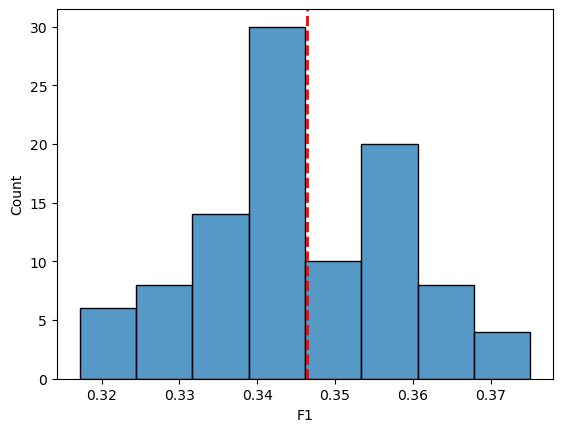

In [98]:
from sklearn.metrics import roc_auc_score
np.random.seed(42)

bootstrap_iterations = 100

df = pd.DataFrame(data={
    "y_test": y_test,
    "y_pred": y_pred,
})

scores = pd.DataFrame(data={
    "F1": 0.0, "P": 0.0, "R": 0.0, "AUC": 0.0
}, index=range(bootstrap_iterations))

for i in range(bootstrap_iterations):
    sample = df.sample(frac=1.0, replace=True)
    scores.loc[i, "F1"] = f1_score(sample["y_test"], sample["y_pred"])
    scores.loc[i, "P"] = precision_score(sample["y_test"], sample["y_pred"])
    scores.loc[i, "R"] = recall_score(sample["y_test"], sample["y_pred"])
    scores.loc[i, "AUC"] = roc_auc_score(sample["y_test"], sample["y_pred"])

ax = sns.histplot(
    x=scores["F1"] 
)

ax.axvline(x=F1, color="red", linestyle="dashed", linewidth=2);

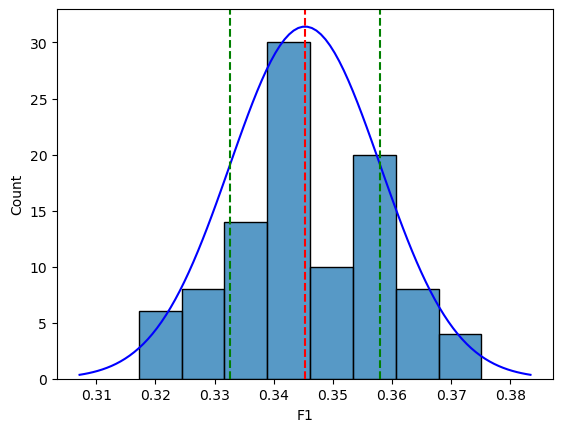

In [14]:
f1_mean = scores["F1"].mean()
f1_std = scores["F1"].std()


f1_low = f1_mean - 3 * f1_std
f1_upp = f1_mean + 3 * f1_std


ax = sns.histplot(
    x=scores["F1"] 
)

x = np.linspace(f1_low, f1_upp, 100)
y = norm.pdf(x, loc=f1_mean, scale=f1_std)
ax.plot(x, y, color="blue")
ax.axvline(f1_mean, color="red", linestyle='dashed')
ax.axvline(f1_mean-f1_std, color="green", linestyle='dashed')
ax.axvline(f1_mean+f1_std, color="green", linestyle='dashed');

## Подбор гипрепараметров

In [99]:
pipe

Pipeline(steps=[('vectorizer', CountVectorizer(analyzer='char')),
                ('classifier',
                 RandomForestClassifier(max_depth=9, n_estimators=35, n_jobs=1,
                                        random_state=42))])

In [100]:
params_grid = {
    "classifier__n_estimators": range(50, 70, 10),
    "classifier__max_depth": range(15, 20),
}

random_search_res = RandomizedSearchCV(
    pipe,
    params_grid,
    n_iter=100,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    refit=True,
    random_state=42,
).fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [101]:
random_search_res.best_params_

{'classifier__n_estimators': 50, 'classifier__max_depth': 19}

In [102]:
y_pred_candidate = random_search_res.predict(X_test)
P_candidate, R_candidate, F1_candidate, _ = precision_recall_fscore_support(y_test, y_pred_candidate, average="binary")
print(f"P_candidate: {P_candidate:.2f}, R_candidate: {R_candidate:.2f}, F1_candidate: {F1_candidate:.5f}")

P_candidate: 0.92, R_candidate: 0.43, F1_candidate: 0.58647


## Упражнение 2

1. Постройте с помощью booststrap выборку оценки $F_1$ для лучшей модели после подбора гиперпарамтеров.
2. Сравните с помощью t-теста базовую модель и кандидата. Примите $\alpha = 0.01$
3. Попробуйте расширить пространство гипрепараметров, чтобы поиск выдал лучший результат


$$n = \frac{2(Z_{\alpha / 2} + Z_{\beta})^2 \sigma^2}{\delta^2}$$

$Z_{\alpha / 2}$ - критическое значение, соответствующее искомому уровню значимости $\alpha / 2$. Берется $\alpha / 2$ потому, что мы рассматриваем двусторонний тест. Значение $\alpha$ определяет уровень допустимости ошибки первого рода. Как правило $\alpha$ берется 0.05 для обычных исследовний и 0.01 для случая медицинских исследований или иных, где ошибка первого рода (отвергнута верная нулевая гипотеза) является критически важной.

$Z_\beta$ - критическое значение, соотвествующее заданному уровню статистической мощности. Значение $\beta$ определяет вероятность ошибки второго рода (принята неверная нулевая гипотеза). Как правило $\beta$ устанавливается на уровне 0.8 или 0.9.

$\sigma$ - стандартное отклонение

$\delta$ - размер эффекта, который необходимо выловить

In [18]:
from sklearn.metrics import roc_auc_score
df_cand = pd.DataFrame(data={
    "y_test": y_test,
    "y_pred": y_pred_candidate,
})

scores_cand = pd.DataFrame(data={
    "F1": 0.0, "P": 0.0, "R": 0.0, "AUC": 0.0
}, index=range(bootstrap_iterations))

for i in range(bootstrap_iterations):
    sample = df_cand.sample(frac=1.0, replace=True)
    scores_cand.loc[i, "F1"] = f1_score(sample["y_test"], sample["y_pred"])
    scores_cand.loc[i, "P"] = precision_score(sample["y_test"], sample["y_pred"])
    scores_cand.loc[i, "R"] = recall_score(sample["y_test"], sample["y_pred"])
    scores_cand.loc[i, "AUC"] = roc_auc_score(sample["y_test"], sample["y_pred"])

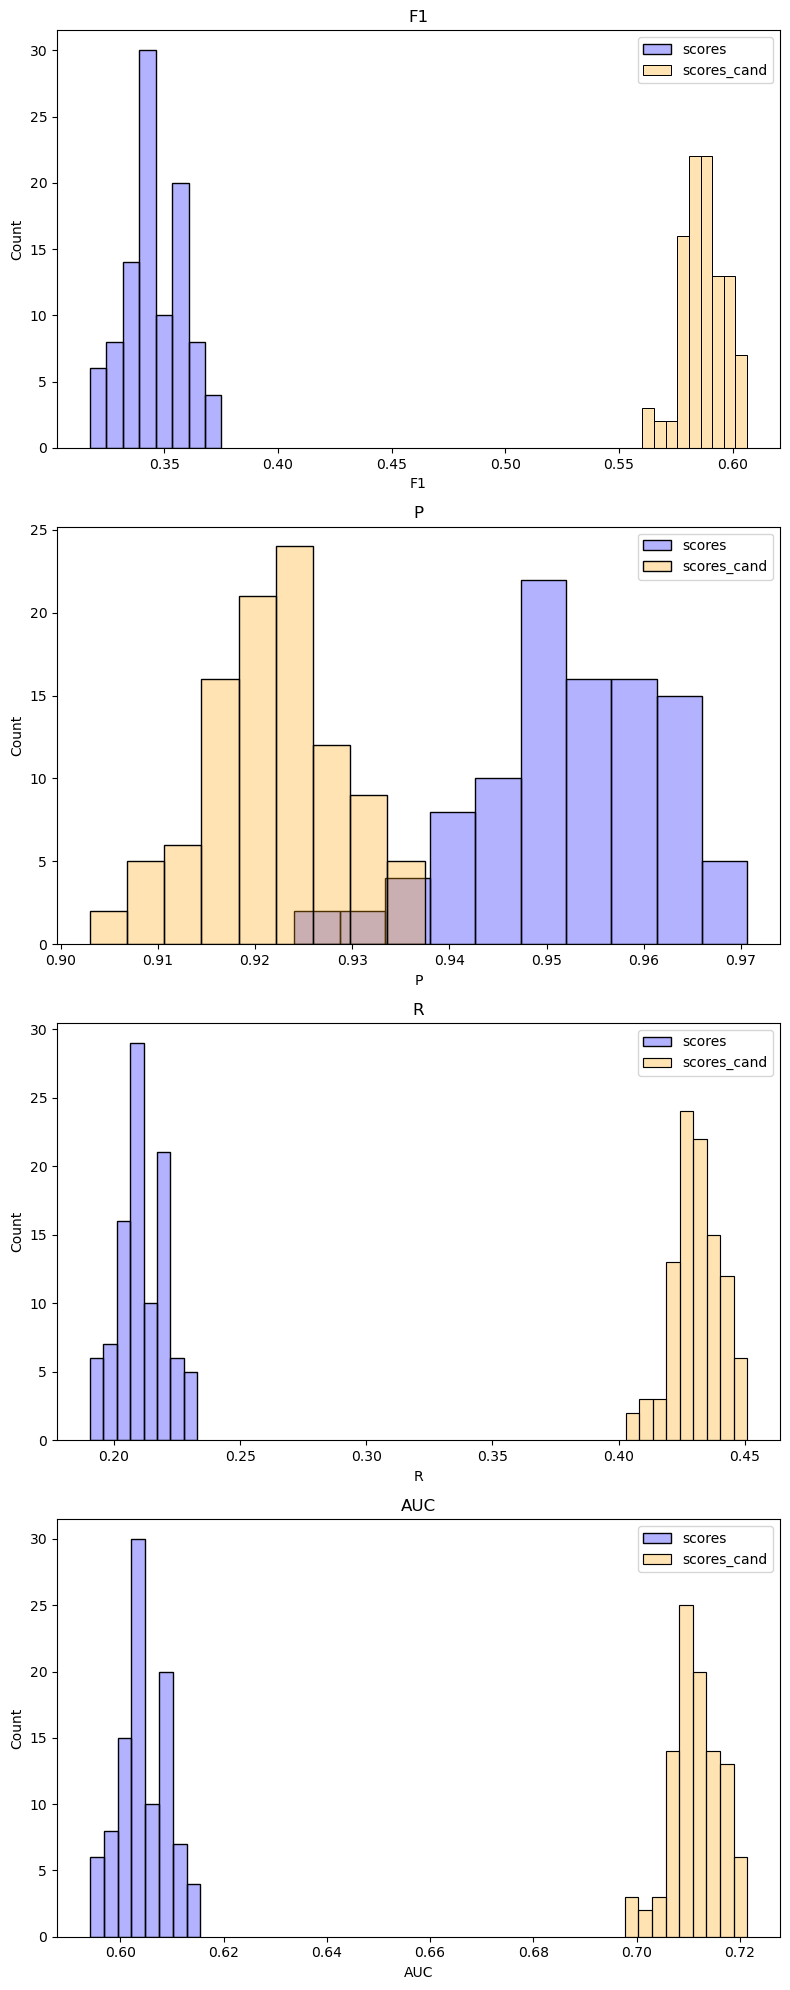

In [19]:
# Loop through the columns
columns_to_plot = ['F1', 'P', 'R', 'AUC']

# Create a figure and axis for the plot
fig, axes = plt.subplots(len(columns_to_plot), 1, figsize=(8, 5*len(columns_to_plot)))


for i, column in enumerate(columns_to_plot):
    # Plot histograms for each dataset
    sns.histplot(data=scores, x=column, ax=axes[i], color='blue', label='scores', alpha=0.3)
    sns.histplot(data=scores_cand, x=column, ax=axes[i], color='orange', label='scores_cand', alpha=0.3)

    # Set plot labels and titles
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{column}')

    # Add legend
    axes[i].legend()

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

In [20]:
alpha = 0.01

for name in ['F1', 'P']:
    # p-value for F1 score
    pvalue = ttest_ind(scores[name], scores_cand[name]).pvalue

    print(f"p-value ({name}): {pvalue:g}\t-\t", end='')
    if pvalue < alpha:
        print("Reject null hypothesis.")
    else:
        print("Accept null hypothesis.")


p-value (F1): 1.65834e-207	-	Reject null hypothesis.
p-value (P): 3.10641e-64	-	Reject null hypothesis.


In [21]:
import numpy as np
mean = scores['P'].mean()
std_error = scores['P'].std() / np.sqrt(len(scores['P']))
confidence_level = 0.95

confidence_interval = stats.t.interval(confidence_level, len(scores)-1, mean, std_error)
print(f'Confidence interval for precision: {confidence_interval[0]:.4f} <- {scores["P"].mean():.4f} -> {confidence_interval[1]:.4f}')


Confidence interval for precision: 0.9503 <- 0.9522 -> 0.9541
